<a href="https://colab.research.google.com/github/Sibitenda/PhDumu/blob/main/big_data/bigquery_practical_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BigQuery Practical Notebook

Group 3: Cloud Query Systems and Data Lake Access

## 0. Setup

In [1]:
!pip install google-cloud-bigquery pandas matplotlib --quiet

In [3]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import auth
auth.authenticate_user()

client = bigquery.Client()

## Part A: Data Access via Query Engine

In [6]:
!gcloud config set project your-project-id

Are you sure you wish to set property [core/project] to your-project-id?

Do you want to continue (Y/n)?  y

Updated property [core/project].


In [12]:
PROJECT_ID = "bigdata1-491608"  # put yours

from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

In [15]:
from google.colab import auth
auth.authenticate_user()

PROJECT_ID = "bigdata1-491608"  # REQUIRED

from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

query = '''
SELECT name, gender, year, number
FROM `bigquery-public-data.usa_names.usa_1910_current`
WHERE year >= 2015
LIMIT 10000
'''

df = client.query(query).to_dataframe()
df.head()

,name,gender,year,number
0,Olivia,F,2015,56
1,Emma,F,2015,49
2,Aurora,F,2015,46
3,Ava,F,2015,41
4,Amelia,F,2015,39


In [16]:
df.shape

(10000, 4)

## Part B: Data Reduction Using SQL

In [17]:
query_reduced = '''
SELECT gender, year, SUM(number) as total_births
FROM `bigquery-public-data.usa_names.usa_1910_current`
WHERE year >= 2015
GROUP BY gender, year
ORDER BY year
'''

df_reduced = client.query(query_reduced).to_dataframe()
df_reduced.head()

,gender,year,total_births
0,F,2015,1458158
1,M,2015,1677553
2,F,2016,1446451
3,M,2016,1654612
4,F,2017,1405262


## Part C: Exploratory Data Analysis

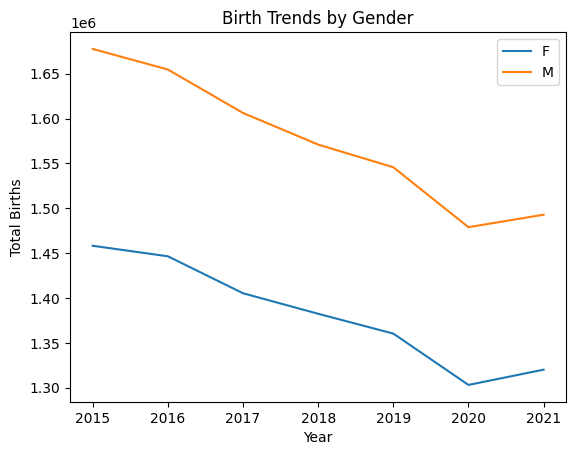

In [18]:
for gender in df_reduced['gender'].unique():
    subset = df_reduced[df_reduced['gender'] == gender]
    plt.plot(subset['year'], subset['total_births'], label=gender)

plt.legend()
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.title("Birth Trends by Gender")
plt.show()

## Part D: Feature Engineering

In [19]:
df_reduced['growth_rate'] = df_reduced.groupby('gender')['total_births'].pct_change()
df_reduced.head()

,gender,year,total_births,growth_rate
0,F,2015,1458158,<NA>
1,M,2015,1677553,<NA>
2,F,2016,1446451,-0.008029
3,M,2016,1654612,-0.013675
4,F,2017,1405262,-0.028476


In [21]:
query = """
SELECT
  date_local,
  AVG(arithmetic_mean) AS avg_pm25
FROM
  `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
WHERE
  city_name = 'San Francisco'
  AND state_name = 'California'
  AND date_local >= '2020-01-01'
GROUP BY
  date_local
ORDER BY
  date_local
"""

df = client.query(query).to_dataframe()
df.head()

,date_local,avg_pm25
0,2020-01-01,8.908334
1,2020-01-02,9.112500
2,2020-01-03,16.316667
3,2020-01-04,6.929167
4,2020-01-05,5.133333


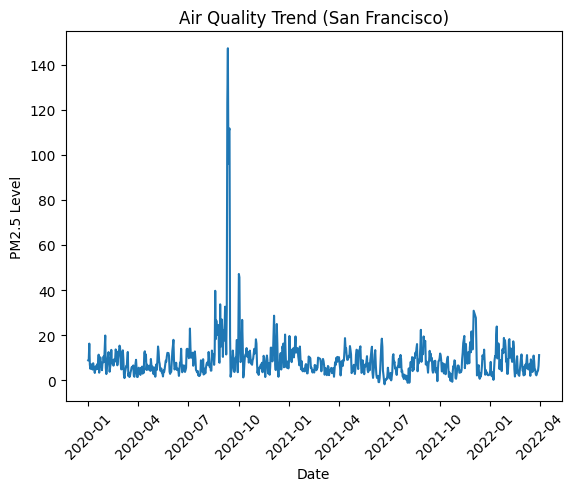

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['date_local'], df['avg_pm25'])
plt.xlabel("Date")
plt.ylabel("PM2.5 Level")
plt.title("Air Quality Trend (San Francisco)")
plt.xticks(rotation=45)
plt.show()

In [29]:
query = """
SELECT
  country_region,
  date,
  confirmed,
  deaths,
  recovered
FROM
  `bigquery-public-data.covid19_jhu_csse.summary`
WHERE
  country_region IN ('Uganda', 'Kenya', 'Tanzania')
  AND date >= '2020-01-01'
ORDER BY date
LIMIT 1000
"""

df = client.query(query).to_dataframe()
df.head()

,country_region,date,confirmed,deaths,recovered
0,Kenya,2020-03-13,1,0,0
1,Kenya,2020-03-14,1,0,0
2,Kenya,2020-03-15,3,0,0
3,Tanzania,2020-03-16,1,0,0
4,Kenya,2020-03-16,3,0,0


In [30]:
df.shape

(1000, 5)

## Part E: Analytical Insights

Write your observations here.

## Part F: Infrastructure Reflection

Discuss BigQuery abstraction, limitations, and hidden infrastructure.

In [42]:
import requests
import pandas as pd

url = "https://api.worldbank.org/v2/region/Africa/country?format=json&per_page=1000"

response = requests.get(url)
data = response.json()

if isinstance(data, list) and len(data) > 1:
    records = data[1]
    df = pd.DataFrame(records)
    print(df.head())
else:
    print("API Error:", data)
df.head()

API Error: [{'message': [{'id': '120', 'key': 'Invalid value', 'value': 'The provided parameter value is not valid'}]}]


,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ASM,AS,American Samoa,"{'id': 'EAS', 'iso2code': 'Z4', 'value': 'East...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Pago Pago,-170.691,-14.2846
1,AUS,AU,Australia,"{'id': 'EAS', 'iso2code': 'Z4', 'value': 'East...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Canberra,149.129,-35.282
2,BRN,BN,Brunei Darussalam,"{'id': 'EAS', 'iso2code': 'Z4', 'value': 'East...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Bandar Seri Begawan,114.946,4.94199
3,CHN,CN,China,"{'id': 'EAS', 'iso2code': 'Z4', 'value': 'East...","{'id': 'EAP', 'iso2code': '4E', 'value': 'East...","{'id': 'UMC', 'iso2code': 'XT', 'value': 'Uppe...","{'id': 'IBD', 'iso2code': 'XF', 'value': 'IBRD'}",Beijing,116.286,40.0495
4,FJI,FJ,Fiji,"{'id': 'EAS', 'iso2code': 'Z4', 'value': 'East...","{'id': 'EAP', 'iso2code': '4E', 'value': 'East...","{'id': 'UMC', 'iso2code': 'XT', 'value': 'Uppe...","{'id': 'IDB', 'iso2code': 'XH', 'value': 'Blend'}",Suva,178.399,-18.1149
